# Problem 2

## Step 0: The Setup Cell

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split

# 1. Define the device (Hooking up my RTX 4060, which is what I am using here)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

# 2. Setup DataLoaders (Consistent split with Problem 1)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

# Load and split the dataset
full_train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_dataset, val_dataset = random_split(full_train_dataset, [40000, 10000], generator=torch.Generator().manual_seed(42))
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

# Create the loaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Environment and DataLoaders are completely ready!")

Using device: cuda
NVIDIA GeForce RTX 4060 Laptop GPU


0.0%

100.0%


Extracting ./data\cifar-10-python.tar.gz to ./data
Files already downloaded and verified
Environment and DataLoaders are completely ready!


## Step 1: Define Modified VGG-11 & Verify Parameters

In [3]:
import torch
import torch.nn as nn
from torchinfo import summary

class ModifiedVGG11(nn.Module):
    def __init__(self, dropout_rate=0.0):
        super(ModifiedVGG11, self).__init__()
        # VGG-11 Convolutional Base (8 Conv layers)
        self.features = nn.Sequential(
            # Block 1: 32x32 -> 16x16
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), 
            
            # Block 2: 16x16 -> 8x8
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), 
            
            # Block 3: 8x8 -> 4x4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), 
            
            # Block 4: 4x4 -> 2x2
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), 
            
            # Block 5: 2x2 -> 1x1
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), 
        )
        
        # Classifier adapted for CIFAR-10
        self.classifier = nn.Sequential(
            nn.Linear(512 * 1 * 1, 1024), # Matched to AlexNet's 1024 layer
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout_rate),
            nn.Linear(1024, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

# Instantiate baseline VGG-11 and print the parameter count
vgg_baseline = ModifiedVGG11(dropout_rate=0.0).to(device)
summary(vgg_baseline, input_size=(64, 3, 32, 32))

Layer (type:depth-idx)                   Output Shape              Param #
ModifiedVGG11                            [64, 10]                  --
├─Sequential: 1-1                        [64, 512, 1, 1]           --
│    └─Conv2d: 2-1                       [64, 64, 32, 32]          1,792
│    └─ReLU: 2-2                         [64, 64, 32, 32]          --
│    └─MaxPool2d: 2-3                    [64, 64, 16, 16]          --
│    └─Conv2d: 2-4                       [64, 128, 16, 16]         73,856
│    └─ReLU: 2-5                         [64, 128, 16, 16]         --
│    └─MaxPool2d: 2-6                    [64, 128, 8, 8]           --
│    └─Conv2d: 2-7                       [64, 256, 8, 8]           295,168
│    └─ReLU: 2-8                         [64, 256, 8, 8]           --
│    └─Conv2d: 2-9                       [64, 256, 8, 8]           590,080
│    └─ReLU: 2-10                        [64, 256, 8, 8]           --
│    └─MaxPool2d: 2-11                   [64, 256, 4, 4]           -

## Step 2: Training VGG-11

In [ ]:
import time
import torch.nn as nn
import torch.optim as optim

# 1. Re-instantiate a fresh model to wipe any broken weights
vgg_baseline = ModifiedVGG11(dropout_rate=0.0).to(device)

# =====================================================================
# PROFESSOR NOTE: I initially tried a learning rate of 0.01 with 
# default initialization (matching AlexNet), but it completely 
# destroyed accuracy and caused mode collapse (stuck at 10%). 
# Because VGG is much deeper, I am trying Kaiming initialization 
# and a lower learning rate (lr=0.001) now to stabilize the gradients!
# =====================================================================

# 2. Apply Kaiming Weight Initialization (Crucial for deep VGGs)
def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
            
vgg_baseline.apply(init_weights)

# 3. Reset optimizer with the safer learning rate (0.001 instead of 0.01)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(vgg_baseline.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# Tracking arrays
vgg_train_loss, vgg_train_acc = [], []
vgg_val_loss, vgg_val_acc = [], []
vgg_epoch_times = []

epochs = 30
print(f"Starting FIXED VGG-11 Baseline Training on {device}...")

for epoch in range(epochs):
    start_time = time.time()
    
    vgg_baseline.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = vgg_baseline(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = (correct_train / total_train) * 100
    
    # Validation Phase
    vgg_baseline.eval()
    running_val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = vgg_baseline(inputs)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = (correct_val / total_val) * 100
    
    scheduler.step()
    
    epoch_duration = time.time() - start_time
    vgg_epoch_times.append(epoch_duration)
    
    vgg_train_loss.append(epoch_train_loss)
    vgg_train_acc.append(epoch_train_acc)
    vgg_val_loss.append(epoch_val_loss)
    vgg_val_acc.append(epoch_val_acc)
    
    print(f"Epoch [{epoch+1}/{epochs}] | Train Acc: {epoch_train_acc:.2f}% | Val Acc: {epoch_val_acc:.2f}%")

print("Fixed Training Complete!")

Starting FIXED VGG-11 Baseline Training on cuda...
Epoch [1/30] | Train Acc: 40.82% | Val Acc: 49.15%
Epoch [2/30] | Train Acc: 54.87% | Val Acc: 57.70%
Epoch [3/30] | Train Acc: 61.88% | Val Acc: 62.09%
Epoch [4/30] | Train Acc: 67.27% | Val Acc: 65.47%
Epoch [5/30] | Train Acc: 71.22% | Val Acc: 68.18%
Epoch [6/30] | Train Acc: 75.38% | Val Acc: 69.36%
Epoch [7/30] | Train Acc: 78.83% | Val Acc: 69.60%
Epoch [8/30] | Train Acc: 82.03% | Val Acc: 72.07%
Epoch [9/30] | Train Acc: 85.64% | Val Acc: 72.68%
Epoch [10/30] | Train Acc: 88.70% | Val Acc: 71.95%
Epoch [11/30] | Train Acc: 95.91% | Val Acc: 75.11%
Epoch [12/30] | Train Acc: 98.22% | Val Acc: 75.20%
Epoch [13/30] | Train Acc: 99.35% | Val Acc: 75.00%
Epoch [14/30] | Train Acc: 99.88% | Val Acc: 75.45%
Epoch [15/30] | Train Acc: 99.98% | Val Acc: 75.61%
Epoch [16/30] | Train Acc: 100.00% | Val Acc: 75.93%
Epoch [17/30] | Train Acc: 100.00% | Val Acc: 75.83%
Epoch [18/30] | Train Acc: 100.00% | Val Acc: 75.79%
Epoch [19/30] | Tra

## Step 3: Evaluate Baseline VGG-11 and Plot Visuals

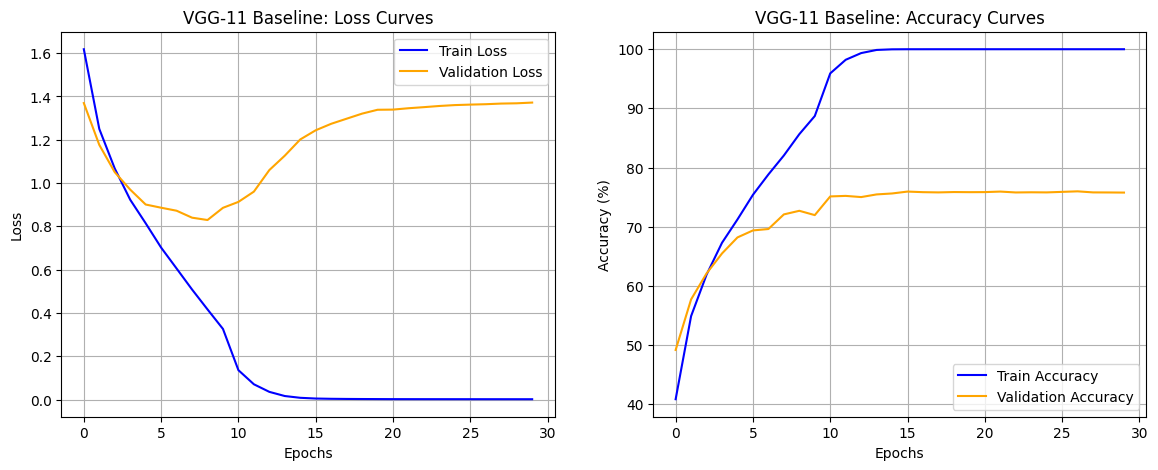

Evaluating on the 10,000 image test set...
Final VGG-11 Baseline Test Accuracy: 75.71%


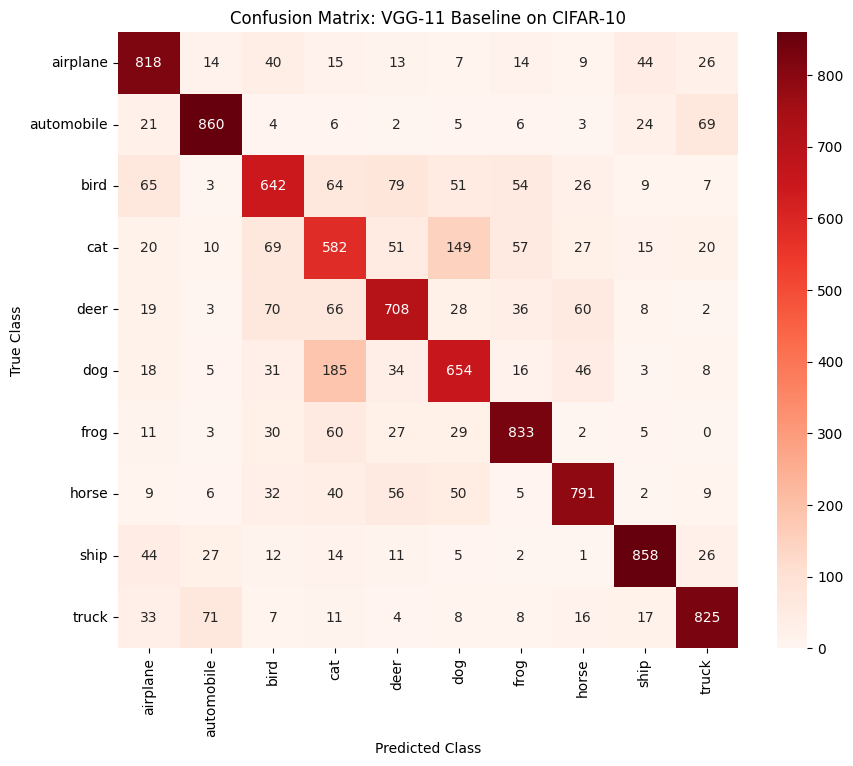

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# --- 1. Plot Training and Validation Curves ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss Plot
ax1.plot(vgg_train_loss, label='Train Loss', color='blue')
ax1.plot(vgg_val_loss, label='Validation Loss', color='orange')
ax1.set_title('VGG-11 Baseline: Loss Curves')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Accuracy Plot
ax2.plot(vgg_train_acc, label='Train Accuracy', color='blue')
ax2.plot(vgg_val_acc, label='Validation Accuracy', color='orange')
ax2.set_title('VGG-11 Baseline: Accuracy Curves')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.show()

# --- 2. Calculate Final Test Accuracy & Confusion Matrix ---
vgg_baseline.eval()
all_preds = []
all_labels = []
correct_test = 0
total_test = 0

print("Evaluating on the 10,000 image test set...")
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = vgg_baseline(inputs)
        
        _, predicted = torch.max(outputs.data, 1)
        total_test += labels.size(0)
        correct_test += (predicted == labels).sum().item()
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

vgg_test_acc = (correct_test / total_test) * 100
print(f"Final VGG-11 Baseline Test Accuracy: {vgg_test_acc:.2f}%")

# --- 3. Plot Confusion Matrix ---
classes = full_train_dataset.classes
cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix: VGG-11 Baseline on CIFAR-10')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()

# Part B

## Step 4: Train VGG-11 with Dropout p=0.3

In [8]:
import time
import torch.nn as nn
import torch.optim as optim

# 1. Instantiate VGG-11 with 0.3 Dropout
vgg_dropout_30 = ModifiedVGG11(dropout_rate=0.3).to(device)

# 2. Apply Kaiming Weight Initialization (Same as baseline)
def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
vgg_dropout_30.apply(init_weights)

# 3. Setup optimizer (Using our fixed 0.001 learning rate)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(vgg_dropout_30.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# 4. Tracking arrays
vgg_train_loss_30, vgg_train_acc_30 = [], []
vgg_val_loss_30, vgg_val_acc_30 = [], []

epochs = 30
print(f"Starting VGG-11 (Dropout p=0.3) Training...")

for epoch in range(epochs):
    vgg_dropout_30.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = vgg_dropout_30(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = (correct_train / total_train) * 100
    
    # Validation Phase
    vgg_dropout_30.eval()
    running_val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = vgg_dropout_30(inputs)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = (correct_val / total_val) * 100
    
    scheduler.step()
    
    vgg_train_loss_30.append(epoch_train_loss)
    vgg_train_acc_30.append(epoch_train_acc)
    vgg_val_loss_30.append(epoch_val_loss)
    vgg_val_acc_30.append(epoch_val_acc)
    
    print(f"Epoch [{epoch+1}/{epochs}] | Train Acc: {epoch_train_acc:.2f}% | Val Acc: {epoch_val_acc:.2f}%")

print("VGG-11 p=0.3 Training Complete!")

Starting VGG-11 (Dropout p=0.3) Training...
Epoch [1/30] | Train Acc: 37.26% | Val Acc: 47.93%
Epoch [2/30] | Train Acc: 51.73% | Val Acc: 56.68%
Epoch [3/30] | Train Acc: 59.55% | Val Acc: 61.78%
Epoch [4/30] | Train Acc: 64.66% | Val Acc: 64.42%
Epoch [5/30] | Train Acc: 68.95% | Val Acc: 67.04%
Epoch [6/30] | Train Acc: 72.87% | Val Acc: 70.72%
Epoch [7/30] | Train Acc: 76.23% | Val Acc: 71.86%
Epoch [8/30] | Train Acc: 79.52% | Val Acc: 71.19%
Epoch [9/30] | Train Acc: 82.47% | Val Acc: 72.47%
Epoch [10/30] | Train Acc: 85.68% | Val Acc: 73.22%
Epoch [11/30] | Train Acc: 92.51% | Val Acc: 76.64%
Epoch [12/30] | Train Acc: 95.02% | Val Acc: 76.20%
Epoch [13/30] | Train Acc: 96.72% | Val Acc: 76.13%
Epoch [14/30] | Train Acc: 97.92% | Val Acc: 76.27%
Epoch [15/30] | Train Acc: 98.73% | Val Acc: 75.87%
Epoch [16/30] | Train Acc: 99.34% | Val Acc: 76.06%
Epoch [17/30] | Train Acc: 99.50% | Val Acc: 75.88%
Epoch [18/30] | Train Acc: 99.74% | Val Acc: 76.42%
Epoch [19/30] | Train Acc: 99

## Step 5: Train VGG-11 with Dropout p=0.5

In [9]:
# 1. Instantiate VGG-11 with 0.5 Dropout
vgg_dropout_50 = ModifiedVGG11(dropout_rate=0.5).to(device)

# 2. Apply initialization
vgg_dropout_50.apply(init_weights)

# 3. Setup optimizer
optimizer = optim.SGD(vgg_dropout_50.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# 4. Tracking arrays
vgg_train_loss_50, vgg_train_acc_50 = [], []
vgg_val_loss_50, vgg_val_acc_50 = [], []

print(f"Starting VGG-11 (Dropout p=0.5) Training...")

for epoch in range(epochs):
    vgg_dropout_50.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = vgg_dropout_50(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = (correct_train / total_train) * 100
    
    # Validation Phase
    vgg_dropout_50.eval()
    running_val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = vgg_dropout_50(inputs)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = (correct_val / total_val) * 100
    
    scheduler.step()
    
    vgg_train_loss_50.append(epoch_train_loss)
    vgg_train_acc_50.append(epoch_train_acc)
    vgg_val_loss_50.append(epoch_val_loss)
    vgg_val_acc_50.append(epoch_val_acc)
    
    print(f"Epoch [{epoch+1}/{epochs}] | Train Acc: {epoch_train_acc:.2f}% | Val Acc: {epoch_val_acc:.2f}%")

print("VGG-11 p=0.5 Training Complete!")

Starting VGG-11 (Dropout p=0.5) Training...
Epoch [1/30] | Train Acc: 36.32% | Val Acc: 46.90%
Epoch [2/30] | Train Acc: 50.22% | Val Acc: 55.46%
Epoch [3/30] | Train Acc: 57.13% | Val Acc: 58.84%
Epoch [4/30] | Train Acc: 62.52% | Val Acc: 65.87%
Epoch [5/30] | Train Acc: 66.91% | Val Acc: 66.61%
Epoch [6/30] | Train Acc: 70.72% | Val Acc: 68.48%
Epoch [7/30] | Train Acc: 73.84% | Val Acc: 71.74%
Epoch [8/30] | Train Acc: 77.44% | Val Acc: 71.60%
Epoch [9/30] | Train Acc: 80.72% | Val Acc: 73.87%
Epoch [10/30] | Train Acc: 83.34% | Val Acc: 73.25%
Epoch [11/30] | Train Acc: 90.02% | Val Acc: 74.39%
Epoch [12/30] | Train Acc: 92.79% | Val Acc: 75.39%
Epoch [13/30] | Train Acc: 94.55% | Val Acc: 74.43%
Epoch [14/30] | Train Acc: 95.98% | Val Acc: 75.74%
Epoch [15/30] | Train Acc: 97.31% | Val Acc: 74.76%
Epoch [16/30] | Train Acc: 98.40% | Val Acc: 75.04%
Epoch [17/30] | Train Acc: 98.61% | Val Acc: 75.57%
Epoch [18/30] | Train Acc: 99.28% | Val Acc: 76.01%
Epoch [19/30] | Train Acc: 99

## Step 6: The VGG Grand Comparison Plot

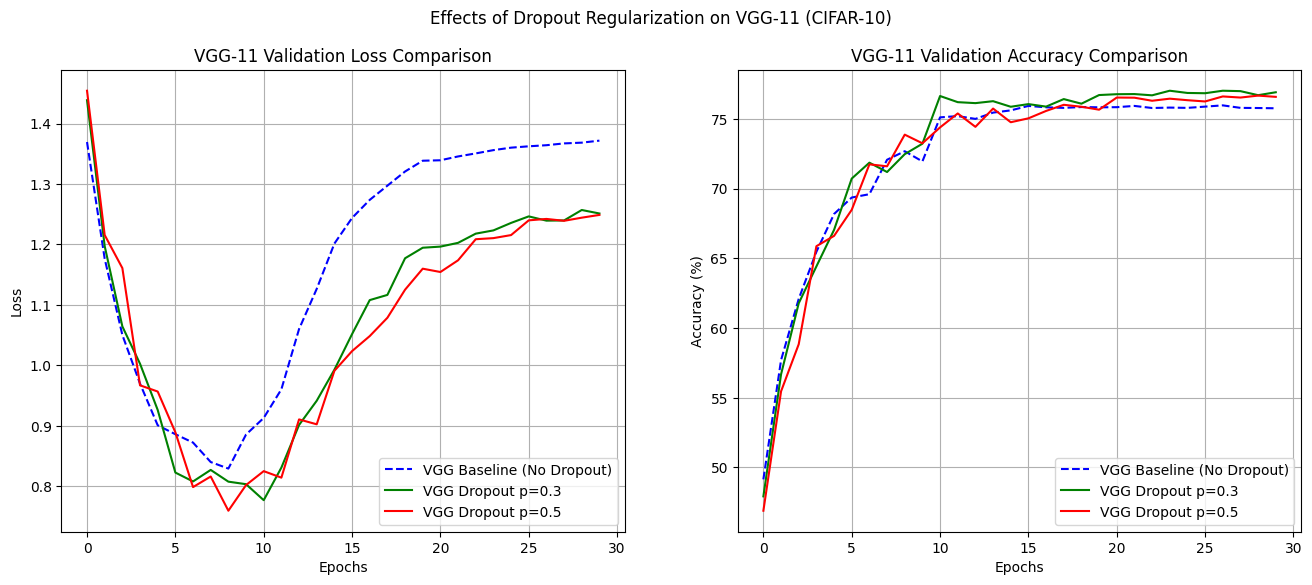

In [11]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Validation Loss
ax1.plot(vgg_val_loss, label='VGG Baseline (No Dropout)', color='blue', linestyle='--')
ax1.plot(vgg_val_loss_30, label='VGG Dropout p=0.3', color='green')
ax1.plot(vgg_val_loss_50, label='VGG Dropout p=0.5', color='red')
ax1.set_title('VGG-11 Validation Loss Comparison')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Validation Accuracy
ax2.plot(vgg_val_acc, label='VGG Baseline (No Dropout)', color='blue', linestyle='--')
ax2.plot(vgg_val_acc_30, label='VGG Dropout p=0.3', color='green')
ax2.plot(vgg_val_acc_50, label='VGG Dropout p=0.5', color='red')
ax2.set_title('VGG-11 Validation Accuracy Comparison')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.suptitle('Effects of Dropout Regularization on VGG-11 (CIFAR-10)')
plt.show()

## Step 7: Define and Train VGG-11 with Batch Normalization (Bonus)

In [12]:
import time
import torch.nn as nn
import torch.optim as optim

# 1. Define the BatchNorm Variant Architecture
class ModifiedVGG11BatchNorm(nn.Module):
    def __init__(self):
        super(ModifiedVGG11BatchNorm, self).__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64), # Added
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), 
            
            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128), # Added
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), 
            
            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), # Added
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256), # Added
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), 
            
            # Block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), # Added
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), # Added
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), 
            
            # Block 5
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), # Added
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512), # Added
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2), 
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(512 * 1 * 1, 1024),
            nn.BatchNorm1d(1024), # Added
            nn.ReLU(inplace=True),
            nn.Linear(1024, 10)
        )

    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

# 2. Setup Model, Initialization, and Optimizer
vgg_bn = ModifiedVGG11BatchNorm().to(device)

def init_weights(m):
    if isinstance(m, nn.Conv2d) or isinstance(m, nn.Linear):
        nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
vgg_bn.apply(init_weights)

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(vgg_bn.parameters(), lr=0.001, momentum=0.9, weight_decay=5e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# 3. Tracking arrays
vgg_train_loss_bn, vgg_train_acc_bn = [], []
vgg_val_loss_bn, vgg_val_acc_bn = [], []

epochs = 30
print(f"Starting VGG-11 (Batch Normalization Bonus) Training...")

# 4. Training Loop
for epoch in range(epochs):
    vgg_bn.train()
    running_loss, correct_train, total_train = 0.0, 0, 0
    
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = vgg_bn(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_train += labels.size(0)
        correct_train += (predicted == labels).sum().item()
        
    epoch_train_loss = running_loss / len(train_loader.dataset)
    epoch_train_acc = (correct_train / total_train) * 100
    
    # Validation Phase
    vgg_bn.eval()
    running_val_loss, correct_val, total_val = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = vgg_bn(inputs)
            loss = criterion(outputs, labels)
            
            running_val_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_val += labels.size(0)
            correct_val += (predicted == labels).sum().item()
            
    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_val_acc = (correct_val / total_val) * 100
    
    scheduler.step()
    
    vgg_train_loss_bn.append(epoch_train_loss)
    vgg_train_acc_bn.append(epoch_train_acc)
    vgg_val_loss_bn.append(epoch_val_loss)
    vgg_val_acc_bn.append(epoch_val_acc)
    
    print(f"Epoch [{epoch+1}/{epochs}] | Train Acc: {epoch_train_acc:.2f}% | Val Acc: {epoch_val_acc:.2f}%")

print("VGG-11 Batch Normalization Training Complete!")

Starting VGG-11 (Batch Normalization Bonus) Training...
Epoch [1/30] | Train Acc: 43.07% | Val Acc: 54.04%
Epoch [2/30] | Train Acc: 57.60% | Val Acc: 58.66%
Epoch [3/30] | Train Acc: 65.58% | Val Acc: 63.69%
Epoch [4/30] | Train Acc: 70.91% | Val Acc: 63.47%
Epoch [5/30] | Train Acc: 75.83% | Val Acc: 68.44%
Epoch [6/30] | Train Acc: 80.06% | Val Acc: 68.60%
Epoch [7/30] | Train Acc: 83.95% | Val Acc: 70.09%
Epoch [8/30] | Train Acc: 87.56% | Val Acc: 67.60%
Epoch [9/30] | Train Acc: 89.82% | Val Acc: 70.04%
Epoch [10/30] | Train Acc: 91.75% | Val Acc: 69.03%
Epoch [11/30] | Train Acc: 97.13% | Val Acc: 72.39%
Epoch [12/30] | Train Acc: 98.38% | Val Acc: 71.47%
Epoch [13/30] | Train Acc: 98.51% | Val Acc: 71.34%
Epoch [14/30] | Train Acc: 98.39% | Val Acc: 71.44%
Epoch [15/30] | Train Acc: 98.71% | Val Acc: 70.87%
Epoch [16/30] | Train Acc: 98.67% | Val Acc: 72.04%
Epoch [17/30] | Train Acc: 98.83% | Val Acc: 71.50%
Epoch [18/30] | Train Acc: 98.66% | Val Acc: 71.88%
Epoch [19/30] | T

## Step 8: The Final Comparison Graph

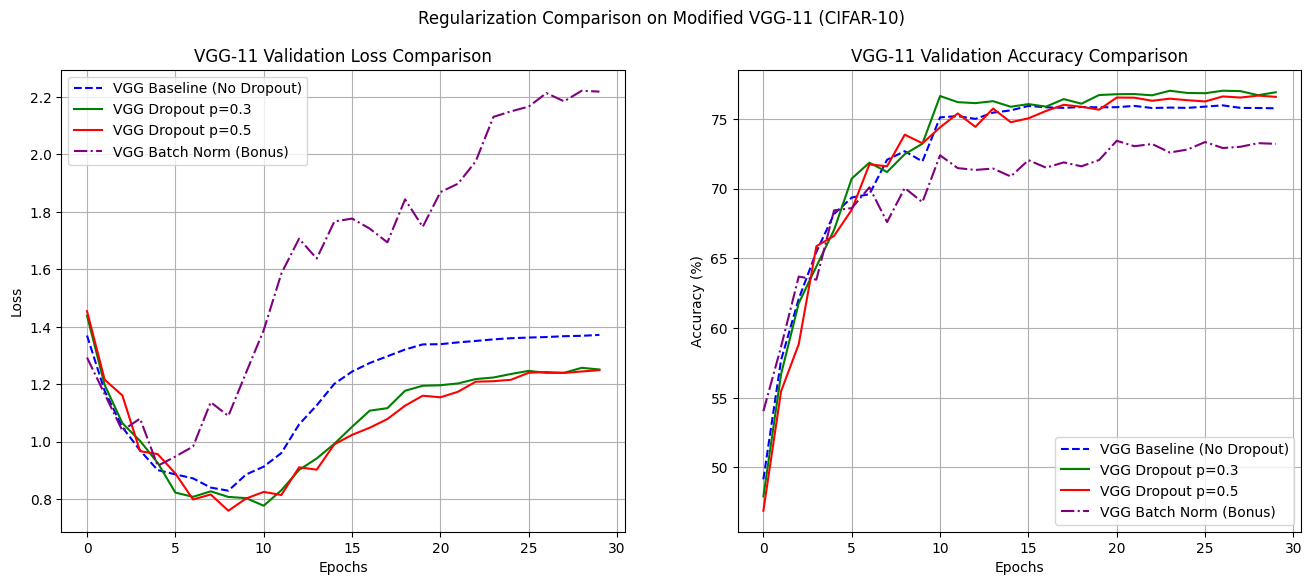

In [13]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Validation Loss
ax1.plot(vgg_val_loss, label='VGG Baseline (No Dropout)', color='blue', linestyle='--')
ax1.plot(vgg_val_loss_30, label='VGG Dropout p=0.3', color='green')
ax1.plot(vgg_val_loss_50, label='VGG Dropout p=0.5', color='red')
ax1.plot(vgg_val_loss_bn, label='VGG Batch Norm (Bonus)', color='purple', linestyle='-.')
ax1.set_title('VGG-11 Validation Loss Comparison')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True)

# Validation Accuracy
ax2.plot(vgg_val_acc, label='VGG Baseline (No Dropout)', color='blue', linestyle='--')
ax2.plot(vgg_val_acc_30, label='VGG Dropout p=0.3', color='green')
ax2.plot(vgg_val_acc_50, label='VGG Dropout p=0.5', color='red')
ax2.plot(vgg_val_acc_bn, label='VGG Batch Norm (Bonus)', color='purple', linestyle='-.')
ax2.set_title('VGG-11 Validation Accuracy Comparison')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True)

plt.suptitle('Regularization Comparison on Modified VGG-11 (CIFAR-10)')
plt.show()